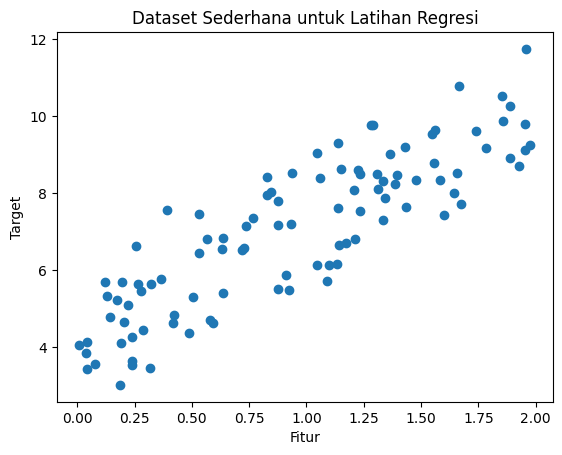

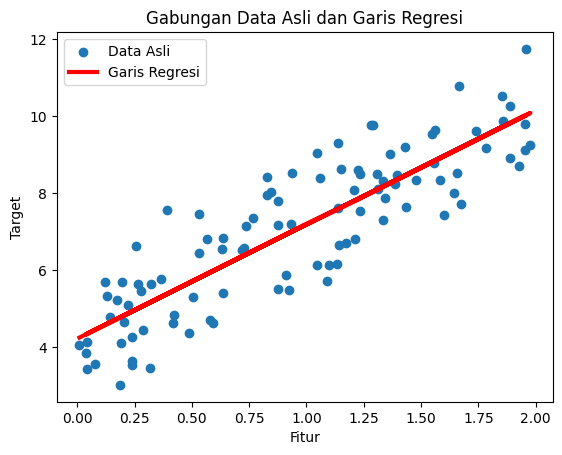

In [13]:
##NAMA : PANDU WIGUNA RUSWANDI (20240040258)
##KELAS : TI24F
##MATKUL : MACHINE LEARNING



import numpy as np
import matplotlib.pyplot as plt

# Buat dataset sederhana
np.random.seed(0)
X = 2 * np.random.rand(100, 1)  # Fitur
y = 4 + 3 * X + np.random.randn(100, 1)  # Target (dengan sedikit noise)

# Plot dataset
plt.scatter(X, y)
plt.xlabel('Fitur')
plt.ylabel('Target')
plt.title('Dataset Sederhana untuk Latihan Regresi')
plt.show()

# 1. Plot titik-titik data (Scatter)
plt.scatter(X, y, label='Data Asli')

# 2. Plot garis regresi (Line)
# Kita gunakan hasil prediksi (y_pred) untuk menarik garisnya
plt.plot(X, y_pred, color='red', linewidth=3, label='Garis Regresi')

# 3. Tambahan aksesori grafik agar rapi
plt.xlabel('Fitur')
plt.ylabel('Target')
plt.title('Gabungan Data Asli dan Garis Regresi')
plt.legend() # Menampilkan keterangan label
plt.show()


In [8]:
from sklearn.linear_model import LinearRegression

# Inisialisasi model regresi linear
model = LinearRegression()

# Latih model menggunakan data
model.fit(X, y)

# Koefisien (slope) dan intersep dari model
slope = model.coef_[0][0]
intercept = model.intercept_[0]

print("Koefisien (slope):", slope)
print("Intersep:", intercept)


Koefisien (slope): 2.968467510701019
Intersep: 4.222151077447231


In [9]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# 1. Prediksi data
y_pred = model.predict(X)

# 2. Hitung Metrik Evaluasi
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)
mape = mean_absolute_percentage_error(y, y_pred)

print("--- EVALUASI REGRESI ---")
print(f"R-Square (10pt): {r2:.4f}")
print(f"MSE (10pt)     : {mse:.4f}")
print(f"RMSE (10pt)    : {rmse:.4f}")
print(f"MAE (10pt)     : {mae:.4f}")
print(f"MAPE (10pt)    : {mape:.4f}")

--- EVALUASI REGRESI ---
R-Square (10pt): 0.7470
MSE (10pt)     : 0.9924
RMSE (10pt)    : 0.9962
MAE (10pt)     : 0.8493
MAPE (10pt)    : 0.1343


--- HASIL REGRESI ---
R-Square: 0.7470
RMSE: 0.9962
MAE: 0.8493
MSE: 0.9924
MAPE: 0.1343

--- HASIL KLASIFIKASI ---
Accuracy: 0.9900
Precision: 1.0000
Recall: 0.9800
F1 Score: 0.9899


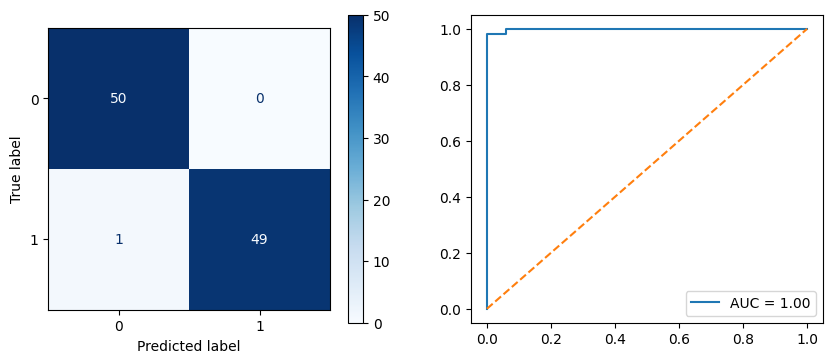

In [10]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay, roc_curve, auc

# --- EVALUASI REGRESI ---
y_pred = model.predict(X)
print("--- HASIL REGRESI ---")
print(f"R-Square: {r2_score(y, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y, y_pred)):.4f}")
print(f"MAE: {mean_absolute_error(y, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y, y_pred):.4f}")
print(f"MAPE: {mean_absolute_percentage_error(y, y_pred):.4f}")

# --- EVALUASI KLASIFIKASI (Contoh Data) ---
Xc, yc = make_classification(n_samples=100, n_features=2, n_redundant=0, random_state=42)
clf = LogisticRegression().fit(Xc, yc)
y_pred_c = clf.predict(Xc)
y_prob_c = clf.predict_proba(Xc)[:, 1]

print("\n--- HASIL KLASIFIKASI ---")
print(f"Accuracy: {accuracy_score(yc, y_pred_c):.4f}")
print(f"Precision: {precision_score(yc, y_pred_c):.4f}")
print(f"Recall: {recall_score(yc, y_pred_c):.4f}")
print(f"F1 Score: {f1_score(yc, y_pred_c):.4f}")

# Plotting Matrix & ROC
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_estimator(clf, Xc, yc, ax=ax[0], cmap='Blues')
fpr, tpr, _ = roc_curve(yc, y_prob_c)
ax[1].plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.2f}")
ax[1].plot([0, 1], linestyle='--')
ax[1].legend()
plt.show()